In [33]:
import pandas as pd 
import numpy as np 
import statsmodels.api as sm 
import matplotlib.pyplot as plt

In [34]:
DF = pd.read_excel('SP500Raw.xlsx')
DF['date'] = pd.to_datetime(DF['date'])
DF = DF.set_index(keys=['date','permno']).copy()
DF

,,price,shrout,prc,mcap
date,permno,,,,
2010-01-29,10104,23.06000,5011220,-0.057888,1.155587e+08
2010-02-26,10104,24.65000,5015000,0.068951,1.236198e+08
2010-03-31,10104,25.71000,5019091,0.043002,1.290408e+08
2010-04-30,10104,25.86750,5029523,0.008071,1.301012e+08
2010-05-28,10104,22.57000,5026000,-0.127477,1.134368e+08
...,...,...,...,...,...
2024-08-30,93436,214.11000,3194640,-0.077391,6.840044e+08
2024-09-30,93436,261.63000,3207000,0.221942,8.390474e+08
2024-10-31,93436,249.85001,3210060,-0.045025,8.020335e+08


## Basic checks of data consistency and visualization 

In [35]:
DF.describe()

,price,shrout,prc,mcap
count,90517.000000,9.052500e+04,90471.000000,9.051700e+04
mean,114.310440,6.208745e+05,0.011204,4.828252e+07
std,230.655848,1.191071e+06,0.085348,1.264082e+08
min,1.480000,3.064000e+03,-0.886269,6.203644e+05
25%,38.660000,1.584690e+05,-0.036248,1.059996e+07
50%,66.720000,3.002210e+05,0.011526,1.955465e+07
75%,118.360000,5.852470e+05,0.057079,4.227438e+07
max,9811.799800,2.920640e+07,2.135168,3.785304e+09


array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'shrout'}>],
       [<Axes: title={'center': 'prc'}>,
        <Axes: title={'center': 'mcap'}>]], dtype=object)

<Figure size 640x480 with 0 Axes>

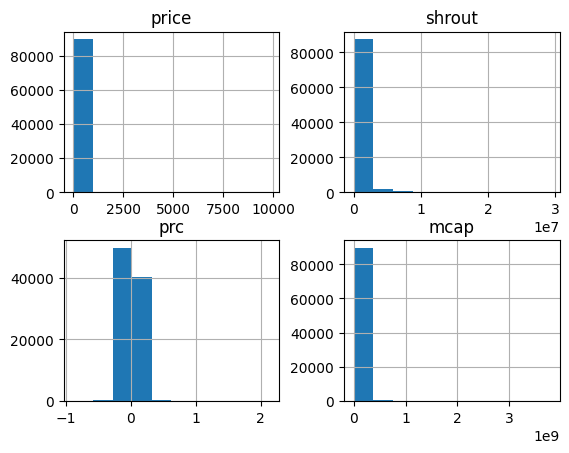

In [36]:
plt.tight_layout()
DF.hist()

In [37]:
DF.isna().sum()

price      8
shrout     0
prc       54
mcap       8
dtype: int64

In [38]:
DF[DF['price'].isna()]


price  shrout  prc  mcap
date       permno                          
2022-10-31 14295     NaN  765246  NaN   NaN
2022-02-28 14704     NaN  399080  NaN   NaN
2015-06-30 25099     NaN   79963  NaN   NaN
2017-12-29 46877     NaN   72892  NaN   NaN
2022-09-30 82686     NaN  126885  NaN   NaN
2010-02-26 84020     NaN  183222  NaN   NaN
2018-11-30 88845     NaN  327400  NaN   NaN
           89014     NaN  164630  NaN   NaN

In [39]:
na_rows = DF[DF['price'].isna()]

for (date, permno), _ in na_rows.iterrows():
    all_prices_for_stock = DF.loc[(slice(None), permno), 'price']
    last_date_in_data = all_prices_for_stock.index.get_level_values('date').max()
    prices_after_na = all_prices_for_stock.loc[date:].dropna()
    is_terminal = (date == last_date_in_data)

    if is_terminal:
        label = "TERMINAL — last row for this stock"
    elif len(prices_after_na) > 0:
        label = "MID-SERIES GAP — valid prices resume later"
    else:
        label = "TRAILING NA — no valid prices after this"

    print(f"permno={permno}  NA on {date.date()}  last date={last_date_in_data.date()}  → {label}")

permno=14295  NA on 2022-10-31  last date=2022-10-31  → TERMINAL — last row for this stock
permno=14704  NA on 2022-02-28  last date=2022-02-28  → TERMINAL — last row for this stock
permno=25099  NA on 2015-06-30  last date=2015-06-30  → TERMINAL — last row for this stock
permno=46877  NA on 2017-12-29  last date=2017-12-29  → TERMINAL — last row for this stock
permno=82686  NA on 2022-09-30  last date=2022-09-30  → TERMINAL — last row for this stock
permno=84020  NA on 2010-02-26  last date=2010-02-26  → TERMINAL — last row for this stock
permno=88845  NA on 2018-11-30  last date=2018-11-30  → TERMINAL — last row for this stock
permno=89014  NA on 2018-11-30  last date=2018-11-30  → TERMINAL — last row for this stock


### Cross-referencing NA-price dates with S&P 500 removal history

| permno | NA date | Likely company | Event |
|--------|---------|----------------|-------|
| 84020 | 2010-02-26 | IMS Health (RX) | Taken private by TPG Capital |
| 25099 | 2015-06-30 | Integrys Energy Group (TEG) | Acquired by Wisconsin Energy |
| 46877 | 2017-12-29 | C.R. Bard (BCR) | Acquired by Becton Dickinson |
| 88845 | 2018-11-30 | Rockwell Collins (COL) or Aetna (AET) | Acquired (United Technologies / CVS) |
| 89014 | 2018-11-30 | The other of the above pair | Same wave of Nov 2018 removals |
| 14704 | 2022-02-28 | IHS Markit (INFO) | Merged with S&P Global |
| 82686 | 2022-09-30 | Penn Entertainment (PENN) or PVH Corp | Removed for market cap decline |
| 14295 | 2022-10-31 | Twitter (TWTR) or Nielsen | Musk acquisition / removed |

**Conclusion:** All 8 NA-price rows correspond to companies leaving the S&P 500, primarily due to M&A. These are terminal observations and can safely be dropped.

In [40]:
DF[DF['prc'].isna()]

price   shrout  prc          mcap
date       permno                                       
2011-01-31 12456    27.87000   294300  NaN  8.202141e+06
2011-07-29 12872    43.79000   356000  NaN  1.558924e+07
2011-11-30 13035    23.90000   184570  NaN  4.411223e+06
2012-01-31 13141    16.48000   197000  NaN  3.246560e+06
2011-12-30 13168    25.21000   120332  NaN  3.033570e+06
2012-05-31 13356    30.03000   625272  NaN  1.877692e+07
2012-10-31 13567    41.51000   229938  NaN  9.544726e+06
           13586    42.24000   210292  NaN  8.882734e+06
           13598    45.46000   592406  NaN  2.693078e+07
2013-01-31 13721    36.69000  1580670  NaN  5.799478e+07
2013-07-31 13963    15.93000   379174  NaN  6.040242e+06
2022-10-31 14295         NaN   765246  NaN           NaN
2013-12-31 14297    44.19000    96000  NaN  4.242240e+06
2014-04-30 14542   526.65997   337247  NaN  1.776145e+08
2014-05-30 14601    15.80000   422739  NaN  6.679276e+06
2022-02-28 14704         NaN   399080  NaN           NaN
2015-07-31 15401    32.83000   544250  NaN  1.786773e+07
           15404    29.18000   317615  NaN  9.268006e+06
           15408    79.47000  1212833  NaN  9.638384e+07
           15488    38.70000  1218736  NaN  4.716508e+07
2015-11-30 15707    14.86000  1798225  NaN  2.672162e+07
           15797    31.51000   138800  NaN  4.373588e+06
2016-04-29 15980    40.80000   217591  NaN  8.877713e+06
2016-07-29 16087    48.21000   345238  NaN  1.664392e+07
2016-10-31 16342    45.51000    93579  NaN  4.258780e+06
2017-01-31 16538    33.62000   466592  NaN  1.568682e+07
2017-08-31 16816    57.07000   119773  NaN  6.835445e+06
2017-09-29 16851    69.23000  2335972  NaN  1.617193e+08
2018-10-31 18143   165.47000   558147  NaN  9.235658e+07
2019-03-29 18420    36.71000   354328  NaN  1.300738e+07
           18421    35.88000   266174  NaN  9.550323e+06
2019-04-30 18428    56.73000   748824  NaN  4.248079e+07
2019-06-28 18592    29.57000   748815  NaN  2.214246e+07
           18724    11.49000  1623530  NaN  1.865436e+07
2020-04-30 19285    17.71000   866159  NaN  1.533968e+07
           19286    50.91000   433079  NaN  2.204805e+07
2020-10-30 19807    28.74000   168447  NaN  4.841167e+06
2020-11-30 20057    16.82000  1200000  NaN  2.018400e+07
2021-06-30 21124    30.26000   253516  NaN  7.671394e+06
2022-02-28 22623    45.98000   326664  NaN  1.502001e+07
2022-04-29 22976    18.15000  2426844  NaN  4.404722e+07
2023-01-31 23570    69.52000   453926  NaN  3.155694e+07
2023-10-31 24174    69.00000   246308  NaN  1.699525e+07
2024-04-30 24877    65.01000   172709  NaN  1.122781e+07
           24878   153.71001   274086  NaN  4.212976e+07
2015-06-30 25099         NaN    79963  NaN           NaN
2024-07-31 25146    44.84000   234790  NaN  1.052798e+07
2024-09-30 25434    32.25000   243302  NaN  7.846490e+06
2017-12-29 46877         NaN    72892  NaN           NaN
2022-09-30 82686         NaN   126885  NaN           NaN
2010-02-26 84020         NaN   183222  NaN           NaN
2018-11-30 88845         NaN   327400  NaN           NaN
           89014         NaN   164630  NaN           NaN
2010-07-30 93422    34.42000   175141  NaN  6.028353e+06

In [41]:
na_prc_rows = DF[DF['prc'].isna()]

for (date, permno), row in na_prc_rows.iterrows():
    all_rows_for_stock = DF.loc[(slice(None), permno), :]
    dates = all_rows_for_stock.index.get_level_values('date')
    first_date = dates.min()
    last_date = dates.max()

    has_price_now = not pd.isna(row['price'])
    prior_dates = dates[dates < date]
    has_price_before = False
    if len(prior_dates) > 0:
        prev_date = prior_dates.max()
        has_price_before = not pd.isna(all_rows_for_stock.loc[(prev_date, permno), 'price'])

    if date == first_date:
        reason = "FIRST OBSERVATION — no prior month to compute return"
    elif not has_price_now and not has_price_before:
        reason = "BOTH PRICES MISSING — no price at t or t-1"
    elif not has_price_now:
        reason = "PRICE MISSING AT t — can't compute return"
    elif not has_price_before:
        reason = "PRICE MISSING AT t-1 — can't compute return from prior month"
    elif date == last_date:
        reason = "LAST OBSERVATION — has price but prc still NA (data issue?)"
    else:
        reason = "UNKNOWN — has prices at t and t-1 but prc is NA"

    print(f"permno={permno}  date={date.date()}  price={'YES' if has_price_now else 'NA'}  prev_price={'YES' if has_price_before else 'NA/NONE'}  → {reason}")

permno=12456  date=2011-01-31  price=YES  prev_price=NA/NONE  → FIRST OBSERVATION — no prior month to compute return
permno=12872  date=2011-07-29  price=YES  prev_price=NA/NONE  → FIRST OBSERVATION — no prior month to compute return
permno=13035  date=2011-11-30  price=YES  prev_price=NA/NONE  → FIRST OBSERVATION — no prior month to compute return
permno=13141  date=2012-01-31  price=YES  prev_price=NA/NONE  → FIRST OBSERVATION — no prior month to compute return
permno=13168  date=2011-12-30  price=YES  prev_price=NA/NONE  → FIRST OBSERVATION — no prior month to compute return
permno=13356  date=2012-05-31  price=YES  prev_price=NA/NONE  → FIRST OBSERVATION — no prior month to compute return
permno=13567  date=2012-10-31  price=YES  prev_price=NA/NONE  → FIRST OBSERVATION — no prior month to compute return
permno=13586  date=2012-10-31  price=YES  prev_price=NA/NONE  → FIRST OBSERVATION — no prior month to compute return
permno=13598  date=2012-10-31  price=YES  prev_price=NA/NONE  → 

In [42]:
DF = DF.dropna(subset=['price'])


In [43]:
DF.isna().sum()

price      0
shrout     0
prc       46
mcap       0
dtype: int64

# Question 2 mismatch between prc and percent change and Price_Ret(T1)

In [44]:
DF['price_ret(t1)'] = DF['price']/DF['price'].shift(1)-1
DF

/var/folders/cf/zk37hd_50bv_nlrdlxrb4q3r0000gn/T/ipykernel_56559/3850811954.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF['price_ret(t1)'] = DF['price']/DF['price'].shift(1)-1


,,price,shrout,prc,mcap,price_ret(t1)
date,permno,,,,,
2010-01-29,10104,23.06000,5011220,-0.057888,1.155587e+08,NaN
2010-02-26,10104,24.65000,5015000,0.068951,1.236198e+08,0.068951
2010-03-31,10104,25.71000,5019091,0.043002,1.290408e+08,0.043002
2010-04-30,10104,25.86750,5029523,0.008071,1.301012e+08,0.006126
2010-05-28,10104,22.57000,5026000,-0.127477,1.134368e+08,-0.127477
...,...,...,...,...,...,...
2024-08-30,93436,214.11000,3194640,-0.077391,6.840044e+08,-0.077390
2024-09-30,93436,261.63000,3207000,0.221942,8.390474e+08,0.221942
2024-10-31,93436,249.85001,3210060,-0.045025,8.020335e+08,-0.045025


In [46]:
match = DF.dropna(subset=['prc', 'price_ret(t1)'])
match['is_equal'] = np.isclose(match['prc'], match['price_ret(t1)'], atol=1e-6)

always_equal = match.groupby('permno')['is_equal'].all()
permnos_always_equal = always_equal[always_equal].index.tolist()

print(f"{len(permnos_always_equal)} out of {len(always_equal)} permnos have prc == price_ret(t1) for every observation")
print(f"\nPermnos where they always match:\n{permnos_always_equal}")

8 out of 794 permnos have prc == price_ret(t1) for every observation

Permnos where they always match:
[12456, 13141, 15488, 16816, 19807, 22976, 24877, 25434]


/var/folders/cf/zk37hd_50bv_nlrdlxrb4q3r0000gn/T/ipykernel_56559/1088250070.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  match['is_equal'] = np.isclose(match['prc'], match['price_ret(t1)'], atol=1e-6)


# Question 3: Company count per date

In [ ]:
companies_per_date = DF.groupby('date').size()

fig, ax = plt.subplots(figsize=(12, 4))
companies_per_date.plot(ax=ax)
ax.set_ylabel('Number of companies')
ax.set_title('Number of S&P 500 companies per month')
ax.axhline(500, color='red', linestyle='--', alpha=0.5, label='500')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Min: {companies_per_date.min()}  Max: {companies_per_date.max()}  Mean: {companies_per_date.mean():.1f}")
print(f"\nDates with fewest companies:")
print(companies_per_date.nsmallest(5))
print(f"\nDates with most companies:")
print(companies_per_date.nlargest(5))

# Question 4: Companies present over the entire sample vs unique companies

In [47]:
all_permnos = DF.index.get_level_values('permno').unique()
all_dates = DF.index.get_level_values('date').unique()

present_every_month = DF.groupby('permno').size()
permnos_full_sample = present_every_month[present_every_month == len(all_dates)].index

print(f"Unique companies in the dataset: {len(all_permnos)}")
print(f"Companies present for every single month ({len(all_dates)} months): {len(permnos_full_sample)}")
print(f"\nThese {len(permnos_full_sample)} 'survivors' were in the S&P 500 for the entire {all_dates.min().date()} to {all_dates.max().date()} period.")

Unique companies in the dataset: 795
Companies present for every single month (180 months): 285

These 285 'survivors' were in the S&P 500 for the entire 2010-01-29 to 2024-12-31 period.


# Question 5: Percentile time series of market cap

In [ ]:
percentiles = [0, 0.05, 0.25, 0.5, 0.75, 0.95, 1.0]
labels = ['min', '5th', '25th', 'median', '75th', '95th', 'max']

mcap_pctiles = DF.groupby('date')['mcap'].quantile(percentiles).unstack()
mcap_pctiles.columns = labels

fig, ax = plt.subplots(figsize=(14, 6))
for col in labels:
    ax.plot(mcap_pctiles.index, mcap_pctiles[col], label=col)
ax.set_ylabel('Market Cap')
ax.set_title('Market Cap Percentiles Over Time')
ax.legend(loc='upper left')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## 5a & 5b: Percentile sets for exiting and entering companies

In [ ]:
last_date_in_data = DF.index.get_level_values('date').max()
first_date_in_data = DF.index.get_level_values('date').min()

# 5a: stocks the month PRIOR to leaving the sample
last_month_per_stock = DF.groupby('permno').apply(lambda g: g.index.get_level_values('date').max())
exiting_permnos = last_month_per_stock[last_month_per_stock < last_date_in_data]

exit_rows = []
for permno, exit_date in exiting_permnos.items():
    stock_dates = DF.loc[(slice(None), permno), :].index.get_level_values('date')
    prior_dates = stock_dates[stock_dates < exit_date]
    if len(prior_dates) > 0:
        prior_date = prior_dates.max()
        exit_rows.append(DF.loc[(prior_date, permno), 'mcap'])

exit_mcaps = pd.Series(exit_rows, name='mcap').dropna()

print("5a: Market cap percentiles for EXITING stocks (month before leaving):")
print(exit_mcaps.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_string())

# 5b: stocks on the month they ENTER the sample
first_month_per_stock = DF.groupby('permno').apply(lambda g: g.index.get_level_values('date').min())
entering_permnos = first_month_per_stock[first_month_per_stock > first_date_in_data]

entry_rows = []
for permno, entry_date in entering_permnos.items():
    entry_rows.append(DF.loc[(entry_date, permno), 'mcap'])

entry_mcaps = pd.Series(entry_rows, name='mcap').dropna()

print(f"\n5b: Market cap percentiles for ENTERING stocks (month of entry):")
print(entry_mcaps.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_string())